# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement


*Air pollution is strongly influenced by weather conditions such as temperature, humidity, precipitation, and wind speed. This project investigates the relationship between weather variables and air quality by combining weather observations collected from the Open-Meteo API with air pollution measurements from a publicly available CSV dataset. The datasets will be assessed, cleaned, merged, and analyzed to identify patterns between weather conditions and pollution levels.*

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1: Historical Weather Data**

**Gathering method:** Accessing an API (Open-Meteo Historical Weather API).

**Why I picked this dataset and method:** I picked hourly weather observations because temperature, humidity, precipitation, and wind speed are well-established drivers of how pollutants disperse or accumulate in the air, making this a natural pairing with the air quality dataset below. I gathered the data by querying Open-Meteo's free historical weather API directly with the `requests` library, which returns clean, structured JSON for any date range and location without requiring an API key.

**Dataset variables and their significance:**
* `time` — the hourly timestamp; used as the key to align weather readings with air quality readings when merging.
* `temperature_2m` — air temperature (°C) at 2 meters; temperature affects how quickly pollutants disperse or accumulate.
* `relative_humidity_2m` — relative humidity (%); can influence particulate matter behavior and formation.
* `precipitation` — rainfall (mm); rain tends to wash pollutants out of the air ("wet deposition").
* `wind_speed_10m` — wind speed (km/h) at 10 meters; a major driver of how quickly pollutants disperse away from a location.


In [1]:
import requests
import pandas as pd

# NOTE: end_date is set generously wide (through end of 2024) so the weather
# data fully covers whatever date range AirQuality.csv spans. Open-Meteo
# ignores/returns extra rows harmlessly; the merge step later will only keep
# rows with a matching timestamp in both datasets, so over-fetching here is
# safe -- but under-fetching (like the original Jan-only range) silently
# drops most of the air quality data during the merge.
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=24.7136&longitude=46.6753"
    "&start_date=2024-01-01"
    "&end_date=2024-12-31"
    "&hourly=temperature_2m,relative_humidity_2m,"
    "precipitation,wind_speed_10m"
)

response = requests.get(url)

weather = pd.DataFrame(response.json()['hourly'])

weather.head()


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2024-01-01T00:00,14.1,90,0.0,9.2
1,2024-01-01T01:00,13.7,91,0.0,9.0
2,2024-01-01T02:00,13.3,93,0.0,11.2
3,2024-01-01T03:00,13.1,93,0.0,13.4
4,2024-01-01T04:00,13.0,93,0.0,12.8


#### **Dataset 2: Air Quality / Pollutant Measurements**

**Gathering method:** Manual download (CSV file downloaded from **[ADD SOURCE HERE — e.g. Kaggle/UCI link]** and saved locally as `AirQuality.csv`).

**Why I picked this dataset and method:** I picked this dataset because it records hourly concentrations of common air pollutants (CO, NOx, NO2, O3, SO2, PM2.5, PM10) alongside on-site weather readings, giving me a direct measure of air quality to compare against the independently-gathered weather dataset above. I downloaded the CSV file manually rather than through an API, which satisfies the requirement to use a second, different data-gathering method alongside Dataset 1's API-based approach.

**Dataset variables and their significance:**
* `Date`, `Time` — combined to build a timestamp used to merge this dataset with the weather data.
* `CO(GT)`, `NOx(GT)`, `NO2(GT)`, `O3(GT)`, `SO2(GT)` — ground-truth concentrations of key gaseous pollutants, the core air-quality measures for this project.
* `PM2.5`, `PM10` — fine and coarse particulate matter concentrations; these are the pollutants most strongly linked to health effects and most sensitive to weather conditions like wind and rain.
* `Temperature`, `Humidity`, `Pressure`, `WindSpeed`, `WindDirection` — on-site weather readings that can be cross-checked against Dataset 1's independently-sourced weather data.
* `CO_NOx_Ratio`, `NOx_NO2_Ratio`, `Temp_Humidity_Index`, `AirQualityIndex`, `CO_MA3`, `NO2_MA3`, `O3_MA3`, `DayOfWeek`, `Hour` — pre-computed ratios, indices, and moving averages included in the source file.


In [2]:
# Load Dataset 2 (manually downloaded CSV) into a DataFrame
air = pd.read_csv("AirQuality.csv")

air.head()

,Date,Time,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,...,WindDirection,CO_NOx_Ratio,NOx_NO2_Ratio,Temp_Humidity_Index,AirQualityIndex,CO_MA3,NO2_MA3,O3_MA3,DayOfWeek,Hour
0,2024-01-01,00:00,3.807947,172.026768,144.333317,118.120832,1.215679,147.349671,208.803124,28.564580,...,209.984267,0.022008,1.183671,3.541778,343.353046,3.807947,144.333317,118.120832,0,0
1,2024-01-01,01:00,9.512072,241.824266,137.769318,15.325830,1.016178,40.979839,145.595579,6.793192,...,319.534890,0.039173,1.742635,0.727989,206.282028,6.660009,141.051317,66.723331,0,1
2,2024-01-01,02:00,7.346740,228.288118,20.055086,44.377036,24.140910,72.594740,26.155000,24.436552,...,274.644300,0.032042,10.842422,7.378322,140.170920,6.888920,100.719240,59.274566,0,2
3,2024-01-01,03:00,6.026719,47.016072,184.591909,139.488603,2.435392,134.339724,276.367944,26.463951,...,312.266023,0.125515,0.253330,21.684266,307.928588,7.628510,114.138771,66.397156,0,3
4,2024-01-01,04:00,1.644585,45.625591,114.125968,95.634768,48.752095,99.007422,294.295449,10.530331,...,21.392120,0.035272,0.396310,9.627596,370.134556,5.006015,106.257654,93.166802,0,4


#### Connection Between the Datasets

Both datasets are gathered at **hourly resolution** and share a common timestamp (`time` in the weather dataset, `Date` + `Time` combined into `Datetime` in the air quality dataset). This shared key is what allows the two datasets to be merged into a single hourly record of weather conditions paired with pollutant levels, which is what the rest of this project uses to explore whether weather variables (temperature, humidity, precipitation, wind speed) are associated with air pollution levels (PM2.5, PM10, NO2, CO, etc.).


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [3]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

Dataset 1

* Missing weather values
* Incorrect data types
* Duplicate timestamps
* Different datetime format

**Issue:** The `time` column in the weather dataset is stored as a string (`object` dtype) rather than a proper `datetime` type.

**Justification:** I found this visually with `weather.sample(5)` — the `time` values print as plain quoted strings — and confirmed it programmatically with `weather.info()` (which reports `time` as `object` instead of `datetime64[ns]`), shown below. Leaving `time` as text would prevent it from being used as a merge key with the air quality dataset and would block any time-based operations (resampling, `.dt` accessors, sorting by actual chronological order). `weather.duplicated().sum()` and `weather.isna().sum()` (also shown below) both come back 0, so duplicates and missing values are not an issue in this particular file -- I checked for them but they aren't present.

### Quality Issue 2:

Dataset 2

* Missing pollution values
* Duplicate rows
* Extra spaces in column names
* Invalid measurements (-200 values)
* Wrong datetime format

In [4]:
# Visual inspection: eyeball a random sample of rows from each dataset
from IPython.display import display

print("Weather sample:")
display(weather.sample(5))

print("\nAir quality sample:")
display(air.sample(5))

Weather sample:


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
5040,2024-07-29T00:00,31.9,17,0.0,14.8
4040,2024-06-17T08:00,40.6,9,0.0,7.7
8017,2024-11-30T01:00,13.3,35,0.0,3.0
2879,2024-04-29T23:00,20.3,66,0.3,25.3
1921,2024-03-21T01:00,14.0,75,0.0,10.2



Air quality sample:


,Date,Time,CO(GT),NOx(GT),NO2(GT),O3(GT),SO2(GT),PM2.5,PM10,Temperature,...,WindDirection,CO_NOx_Ratio,NOx_NO2_Ratio,Temp_Humidity_Index,AirQualityIndex,CO_MA3,NO2_MA3,O3_MA3,DayOfWeek,Hour
2679,2024-04-21,15:00,5.207033,158.746307,57.770321,157.181173,40.092902,156.815654,120.475550,11.570960,...,251.035779,0.032596,2.701130,5.646863,405.859278,2.362038,73.146832,122.880490,6,15
2693,2024-04-22,05:00,4.694542,241.160425,39.409982,118.691437,26.260476,176.017332,24.934618,18.555614,...,201.449031,0.019386,5.967843,15.222061,442.185530,3.628197,81.691974,99.776144,0,5
3921,2024-06-12,09:00,4.062102,213.909526,46.957131,167.135661,18.385270,9.091099,209.689444,13.061633,...,83.802086,0.018901,4.460432,4.064902,208.458730,7.202915,126.782477,155.941315,2,9
40,2024-01-02,16:00,1.308179,259.964362,195.967133,112.607898,6.370296,44.354824,133.770821,-3.958414,...,110.183022,0.005013,1.319836,-0.634406,107.267918,4.213198,153.516848,83.791551,1,16
2009,2024-03-24,17:00,4.926955,76.706473,152.137827,176.708307,9.769129,160.958307,28.286972,8.644066,...,33.031297,0.063405,0.500898,2.315577,167.094875,4.487838,144.698124,125.030133,6,17


In [5]:
# Programmatic check for Quality Issue 2: missing values, invalid
# placeholder values, and duplicate rows in the air quality dataset
print("=== air.info() ===")
air.info()

print("\n=== air.describe() ===")
print(air.describe())

print("\n=== Missing values per column ===")
print(air.isna().sum())

print("\n=== Duplicate rows ===")
print(air.duplicated().sum())

=== air.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 4000 non-null   object 
 1   Time                 4000 non-null   object 
 2   CO(GT)               4000 non-null   float64
 3   NOx(GT)              4000 non-null   float64
 4   NO2(GT)              4000 non-null   float64
 5   O3(GT)               4000 non-null   float64
 6   SO2(GT)              4000 non-null   float64
 7   PM2.5                4000 non-null   float64
 8   PM10                 4000 non-null   float64
 9   Temperature          4000 non-null   float64
 10  Humidity             4000 non-null   float64
 11  Pressure             4000 non-null   float64
 12  WindSpeed            4000 non-null   float64
 13  WindDirection        4000 non-null   float64
 14  CO_NOx_Ratio         4000 non-null   float64
 15  NOx_NO2_Ratio      

In [6]:
# Programmatic check for Quality Issue 1: dtype, missing values,
# and duplicate rows in the weather dataset
print("=== weather.info() ===")
weather.info()

print("\n=== weather.describe() ===")
print(weather.describe())

print("\n=== Missing values per column ===")
print(weather.isna().sum())

print("\n=== Duplicate rows ===")
print(weather.duplicated().sum())

=== weather.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  8784 non-null   object 
 1   temperature_2m        8784 non-null   float64
 2   relative_humidity_2m  8784 non-null   int64  
 3   precipitation         8784 non-null   float64
 4   wind_speed_10m        8784 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 343.3+ KB

=== weather.describe() ===
       temperature_2m  relative_humidity_2m  precipitation  wind_speed_10m
count     8784.000000           8784.000000    8784.000000     8784.000000
mean        27.442293             26.592327       0.005829       13.099624
std          9.223909             17.657156       0.077580        6.740567
min          5.500000              4.000000       0.000000        0.200000
25%         20.200000             13.000000    

**Issue:** The air quality dataset's column names use inconsistent naming conventions -- some include units in parentheses (`CO(GT)`, `NOx(GT)`), some are camelCase (`WindDirection`, `AirQualityIndex`), and some are snake_case abbreviations (`CO_NOx_Ratio`, `CO_MA3`) -- all mixed together in the same table.

**Justification:** The column list from `air.info()` (above) shows these three different naming styles side by side. Mixed conventions like this make columns error-prone to reference programmatically (e.g. easy to mistype `CO(GT)` vs `CO_GT`), and are inconsistent with the rest of the merged dataset once combined with the weather columns, which use a single consistent lowercase/underscore style (`temperature_2m`, `wind_speed_10m`).

### Tidiness Issue 1:

Candidate tidiness issues observed:

* **Air quality dataset:** `Date` and `Time` are stored in two separate columns instead of a single timestamp column — one variable ("when this reading was taken") is split across two columns.
* **Weather & air quality datasets:** hourly weather conditions and hourly pollutant readings for the same point in time are stored in two separate tables instead of one — a single type of observational unit (an hourly reading) is spread across multiple tables.

In [7]:
# Evidence for Tidiness Issue 1: confirm Date and Time are two
# separate columns rather than one timestamp column
print(air.columns.tolist())
air[['Date', 'Time']].sample(5)

['Date', 'Time', 'CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index', 'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour']


,Date,Time
530,2024-01-23,02:00
990,2024-02-11,06:00
3328,2024-05-18,16:00
597,2024-01-25,21:00
3611,2024-05-30,11:00


**Issue:** In the air quality dataset, the timestamp for each reading is split across two separate columns, `Date` and `Time`, instead of being stored as a single `datetime` variable.

**Justification:** Visually, `air[['Date','Time']].sample(5)` (above) shows the date and time as two separate string columns that must be combined before they represent one usable timestamp. Programmatically, `air.columns.tolist()` confirms there is no single datetime column in the raw data. This violates the tidy-data rule that each variable should form its own column — "timestamp" is one variable, not two — and it also blocks merging this dataset with the weather dataset, which is keyed on a single datetime column.

### Tidiness Issue 2: 

In [8]:
# Evidence for Tidiness Issue 2: the two datasets have completely
# different sets of columns, confirming they are separate tables
print("Weather columns:", weather.columns.tolist())
print("Air quality columns:", air.columns.tolist())

Weather columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']
Air quality columns: ['Date', 'Time', 'CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index', 'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour']


In [9]:
# Evidence for Tidiness Issue 2: differing shapes confirm these are
# two separate tables describing the same type of observation
print("Weather shape:", weather.shape)
print("Air quality shape:", air.shape)

Weather shape: (8784, 5)
Air quality shape: (4000, 23)


**Issue:** Weather conditions and air pollutant readings for the same hourly observation are stored in two separate tables (`weather` and `air`) rather than one.

**Justification:** Both datasets describe the same type of observational unit — atmospheric conditions during a given hour — split across two files, so no single row currently captures the full picture (weather *and* pollution) for one hour. This is a classic tidiness violation: "a single observational unit is stored in multiple tables." Comparing `weather.columns.tolist()` and `air.columns.tolist()` (above) shows two disjoint sets of variables describing overlapping timestamps, and the differing shapes confirm they're two separate tables. To analyze how weather relates to pollution, they need to be combined into one table keyed on a shared timestamp.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [10]:
# Make copies of the datasets so the original raw dataframes stay untouched
weather_clean = weather.copy()

air_clean = air.copy()

### **Quality Issue 1: Weather `time` column stored as a string, not a datetime**

In [11]:
# Convert time from string to a proper datetime type
weather_clean['time'] = pd.to_datetime(weather_clean['time'])

In [12]:
# Remove exact duplicate rows
weather_clean.drop_duplicates(inplace=True)

# Forward-fill missing readings -- weather changes gradually hour to hour,
# so carrying the last known reading forward is a reasonable approximation
# for short gaps
weather_clean = weather_clean.ffill()

In [13]:
# Validate the cleaning was successful
print(weather_clean.dtypes)
print("\nDuplicate rows remaining:", weather_clean.duplicated().sum())
print("Missing values remaining:", weather_clean.isna().sum().sum())
weather_clean.head()

time                    datetime64[ns]
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
wind_speed_10m                 float64
dtype: object

Duplicate rows remaining: 0
Missing values remaining: 0


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2024-01-01 00:00:00,14.1,90,0.0,9.2
1,2024-01-01 01:00:00,13.7,91,0.0,9.0
2,2024-01-01 02:00:00,13.3,93,0.0,11.2
3,2024-01-01 03:00:00,13.1,93,0.0,13.4
4,2024-01-01 04:00:00,13.0,93,0.0,12.8


**Justification:** I converted `time` to a proper `datetime` type with `pd.to_datetime()` so it can be used as a merge key and for time-based analysis -- the validation above confirms `time` is now `datetime64[ns]`. The `drop_duplicates()` and `ffill()` calls are kept as a defensive safety net for future data pulls, even though the Assess step found no duplicate rows or missing values in this particular file.

### **Quality Issue 2: Air quality dataset has inconsistent column naming conventions**

In [14]:
# Remove extra whitespace from column names
air_clean.columns = air_clean.columns.str.strip()

In [15]:
# Standardize every column name to a single, consistent snake_case style
# (an explicit mapping is used instead of a generic regex, since the
# domain abbreviations here -- CO, NOx, PM2.5, SO2 -- would be mangled by
# a naive camelCase-splitting regex).
# NOTE: "Date" and "Time" are deliberately left as-is here -- they're still
# needed in their original form for the Tidiness Issue 1 fix below, which
# combines them into "Datetime" and then drops them.
rename_map = {
    "CO(GT)": "co",
    "NOx(GT)": "nox",
    "NO2(GT)": "no2",
    "O3(GT)": "o3",
    "SO2(GT)": "so2",
    "PM2.5": "pm2_5",
    "PM10": "pm10",
    "Temperature": "temperature",
    "Humidity": "humidity",
    "Pressure": "pressure",
    "WindSpeed": "wind_speed",
    "WindDirection": "wind_direction",
    "CO_NOx_Ratio": "co_nox_ratio",
    "NOx_NO2_Ratio": "nox_no2_ratio",
    "Temp_Humidity_Index": "temp_humidity_index",
    "AirQualityIndex": "air_quality_index",
    "CO_MA3": "co_ma3",
    "NO2_MA3": "no2_ma3",
    "O3_MA3": "o3_ma3",
    "DayOfWeek": "day_of_week",
    "Hour": "hour",
}
air_clean.rename(columns=rename_map, inplace=True)

In [16]:
# Forward-fill any missing readings and drop exact duplicate rows,
# as a general safety net even though none were found during Assess
air_clean = air_clean.ffill()
air_clean.drop_duplicates(inplace=True)

In [17]:
# Validate the cleaning was successful
print(air_clean.columns.tolist())
print("\nDuplicate rows remaining:", air_clean.duplicated().sum())
print("Missing values remaining:", air_clean.isna().sum().sum())
air_clean.describe()

['Date', 'Time', 'co', 'nox', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'temperature', 'humidity', 'pressure', 'wind_speed', 'wind_direction', 'co_nox_ratio', 'nox_no2_ratio', 'temp_humidity_index', 'air_quality_index', 'co_ma3', 'no2_ma3', 'o3_ma3', 'day_of_week', 'hour']

Duplicate rows remaining: 0
Missing values remaining: 0


,co,nox,no2,o3,so2,pm2_5,pm10,temperature,humidity,pressure,...,wind_direction,co_nox_ratio,nox_no2_ratio,temp_humidity_index,air_quality_index,co_ma3,no2_ma3,o3_ma3,day_of_week,hour
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,5.025385,148.126633,100.213189,89.914815,26.081045,104.765999,153.591417,17.305228,54.626284,999.862679,...,179.571724,0.082564,3.412176,9.418823,249.602455,5.025846,100.222672,89.901700,2.978000,11.484000
std,2.874632,85.999247,57.074947,52.003484,14.059684,56.344868,83.080911,12.943632,25.844003,28.897118,...,104.738760,0.215593,7.996062,8.982090,143.570929,1.672715,32.884870,30.505331,1.992614,6.919951
min,0.100115,1.009185,1.010513,1.055442,1.012370,5.009384,10.031967,-4.996963,10.000498,950.018004,...,0.033694,0.000389,0.006021,-4.824570,0.052355,0.612983,3.702628,7.453898,0.000000,0.000000
25%,2.514242,73.636615,51.326622,44.179487,14.220565,56.544378,82.200105,6.092531,31.970628,975.018939,...,86.409827,0.017033,0.719052,2.551932,124.521801,3.846779,77.100651,68.321846,1.000000,5.000000
50%,5.054973,146.440690,99.508855,88.956924,26.321359,105.502686,154.714484,17.184773,55.113650,999.857722,...,179.401393,0.034021,1.467460,6.975287,250.552671,5.042259,100.128466,90.452301,3.000000,11.000000
75%,7.524652,221.823697,149.666167,136.333683,37.833728,153.751364,222.969347,28.573093,76.311009,1024.763352,...,272.370032,0.065973,2.789423,14.752847,370.997732,6.206658,123.919621,111.337587,5.000000,17.000000
max,9.997205,299.838744,199.934968,179.986544,49.993700,199.980691,299.911727,39.987944,99.981043,1049.926869,...,359.984504,4.078615,131.169948,39.372679,499.920650,9.471079,190.781333,173.546840,6.000000,23.000000


**Justification:** I standardized every column name to a single, consistent lowercase snake_case style, stripping the `(GT)` unit suffixes and converting camelCase names (e.g. `WindDirection` -> `wind_direction`), so the whole dataset follows one naming convention that's safe to reference programmatically and consistent with the weather dataset's column style. The `ffill()`/`drop_duplicates()` calls are kept as a defensive safety net for future data pulls, even though the Assess step found no missing values or duplicates in this particular file. The validation above confirms the new column names and that no duplicates/missing values were introduced.

### **Tidiness Issue 1: `Date` and `Time` split across two columns in the air quality dataset**

In [18]:
# Combine Date and Time into a single datetime column, then drop the
# now-redundant originals (keeping them would collide with weather_clean's
# own "time" column once the two datasets are merged)
air_clean["Datetime"] = pd.to_datetime(
    air_clean["Date"] + " " + air_clean["Time"]
)
air_clean.drop(columns=["Date", "Time"], inplace=True)

In [19]:
# Validate the cleaning was successful
print(air_clean.columns.tolist())
air_clean[['Datetime']].head()

['co', 'nox', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'temperature', 'humidity', 'pressure', 'wind_speed', 'wind_direction', 'co_nox_ratio', 'nox_no2_ratio', 'temp_humidity_index', 'air_quality_index', 'co_ma3', 'no2_ma3', 'o3_ma3', 'day_of_week', 'hour', 'Datetime']


,Datetime
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00


**Justification:** I combined `Date` and `Time` into a single `Datetime` column with `pd.to_datetime()`, so timestamp information for each row lives in one column instead of two -- satisfying the tidy-data rule that each variable gets its own column -- and so this dataset can be merged with the weather dataset on a shared timestamp.

### **Tidiness Issue 2: Weather and air quality data stored in two separate tables**

## Merge Data

In [20]:
# Combine the two cleaned tables into one, keyed on the shared
# timestamp, so each row is one full hourly weather + pollution reading
merged = pd.merge(
    weather_clean,
    air_clean,
    left_on='time',
    right_on='Datetime',
    how='inner'
)
merged.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,co,nox,no2,o3,so2,...,co_nox_ratio,nox_no2_ratio,temp_humidity_index,air_quality_index,co_ma3,no2_ma3,o3_ma3,day_of_week,hour,Datetime
0,2024-01-01 00:00:00,14.1,90,0.0,9.2,3.807947,172.026768,144.333317,118.120832,1.215679,...,0.022008,1.183671,3.541778,343.353046,3.807947,144.333317,118.120832,0,0,2024-01-01 00:00:00
1,2024-01-01 01:00:00,13.7,91,0.0,9.0,9.512072,241.824266,137.769318,15.325830,1.016178,...,0.039173,1.742635,0.727989,206.282028,6.660009,141.051317,66.723331,0,1,2024-01-01 01:00:00
2,2024-01-01 02:00:00,13.3,93,0.0,11.2,7.346740,228.288118,20.055086,44.377036,24.140910,...,0.032042,10.842422,7.378322,140.170920,6.888920,100.719240,59.274566,0,2,2024-01-01 02:00:00
3,2024-01-01 03:00:00,13.1,93,0.0,13.4,6.026719,47.016072,184.591909,139.488603,2.435392,...,0.125515,0.253330,21.684266,307.928588,7.628510,114.138771,66.397156,0,3,2024-01-01 03:00:00
4,2024-01-01 04:00:00,13.0,93,0.0,12.8,1.644585,45.625591,114.125968,95.634768,48.752095,...,0.035272,0.396310,9.627596,370.134556,5.006015,106.257654,93.166802,0,4,2024-01-01 04:00:00


In [21]:
# Validate the cleaning was successful
print(merged.shape)
merged.info()

(4000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  4000 non-null   datetime64[ns]
 1   temperature_2m        4000 non-null   float64       
 2   relative_humidity_2m  4000 non-null   int64         
 3   precipitation         4000 non-null   float64       
 4   wind_speed_10m        4000 non-null   float64       
 5   co                    4000 non-null   float64       
 6   nox                   4000 non-null   float64       
 7   no2                   4000 non-null   float64       
 8   o3                    4000 non-null   float64       
 9   so2                   4000 non-null   float64       
 10  pm2_5                 4000 non-null   float64       
 11  pm10                  4000 non-null   float64       
 12  temperature           4000 non-null   float64       
 13  humidit

**Justification:** I merged `weather_clean` and `air_clean` into a single `merged` DataFrame with an inner join on the shared timestamp (`time` / `Datetime`), so each row now represents one full hourly observation of weather *and* pollution conditions together, instead of being split across two tables. The row/column counts above confirm the merge kept only timestamps present in both datasets and produced well over the required 4 variables.

## Store Data

In [22]:
# Save the final merged, cleaned dataset to disk
merged.to_csv("clean_weather_air_quality.csv", index=False)

## Exploratory Data Analysis

In [23]:
# Quick summary statistics of the merged dataset before analysis
merged.describe()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,co,nox,no2,o3,so2,...,co_nox_ratio,nox_no2_ratio,temp_humidity_index,air_quality_index,co_ma3,no2_ma3,o3_ma3,day_of_week,hour,Datetime
count,4000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000
mean,2024-03-24 07:29:59.999999744,23.973775,32.774250,0.010175,14.467300,5.025385,148.126633,100.213189,89.914815,26.081045,...,0.082564,3.412176,9.418823,249.602455,5.025846,100.222672,89.901700,2.978000,11.484000,2024-03-24 07:29:59.999999744
min,2024-01-01 00:00:00,5.800000,5.000000,0.000000,0.400000,0.100115,1.009185,1.010513,1.055442,1.012370,...,0.000389,0.006021,-4.824570,0.052355,0.612983,3.702628,7.453898,0.000000,0.000000,2024-01-01 00:00:00
25%,2024-02-11 15:45:00,17.700000,17.000000,0.000000,9.500000,2.514242,73.636615,51.326622,44.179487,14.220565,...,0.017033,0.719052,2.551932,124.521801,3.846779,77.100651,68.321846,1.000000,5.000000,2024-02-11 15:45:00
50%,2024-03-24 07:30:00,22.900000,28.000000,0.000000,13.800000,5.054973,146.440690,99.508855,88.956924,26.321359,...,0.034021,1.467460,6.975287,250.552671,5.042259,100.128466,90.452301,3.000000,11.000000,2024-03-24 07:30:00
75%,2024-05-04 23:15:00,29.800000,45.000000,0.000000,18.700000,7.524652,221.823697,149.666167,136.333683,37.833728,...,0.065973,2.789423,14.752847,370.997732,6.206658,123.919621,111.337587,5.000000,17.000000,2024-05-04 23:15:00
max,2024-06-15 15:00:00,46.100000,100.000000,2.000000,46.600000,9.997205,299.838744,199.934968,179.986544,49.993700,...,4.078615,131.169948,39.372679,499.920650,9.471079,190.781333,173.546840,6.000000,23.000000,2024-06-15 15:00:00
std,NaN,8.505544,20.513739,0.097244,6.742897,2.874632,85.999247,57.074947,52.003484,14.059684,...,0.215593,7.996062,8.982090,143.570929,1.672715,32.884870,30.505331,1.992614,6.919951,NaN


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question 1:* <br>
**How does temperature affect PM2.5?**

In [24]:
# Research Question 1: correlation between temperature and PM2.5
merged[['temperature_2m','pm2_5']].corr()

,temperature_2m,pm2_5
temperature_2m,1.000000,-0.003463
pm2_5,-0.003463,1.000000


*Research question 2:* <br>
**Does wind speed reduce pollution?**

In [25]:
# Research Question 2: correlation between wind speed and PM2.5
merged[['wind_speed_10m','pm2_5']].corr()

,wind_speed_10m,pm2_5
wind_speed_10m,1.000000,0.011815
pm2_5,0.011815,1.000000


*Research question 3:* <br>
**Average pollution by day**

In [26]:
# Research Question 3: average PM2.5 grouped by calendar day
merged.groupby(
    merged['time'].dt.date
)['pm2_5'].mean()

time
2024-01-01     98.511301
2024-01-02     81.741171
2024-01-03    112.990730
2024-01-04    103.786552
2024-01-05    107.715770
                 ...    
2024-06-11    111.363164
2024-06-12     76.516381
2024-06-13    109.090825
2024-06-14    103.713691
2024-06-15     85.395833
Name: pm2_5, Length: 167, dtype: float64

## Visualizations

### Temperature Trend

Text(0, 0.5, 'Temperature')

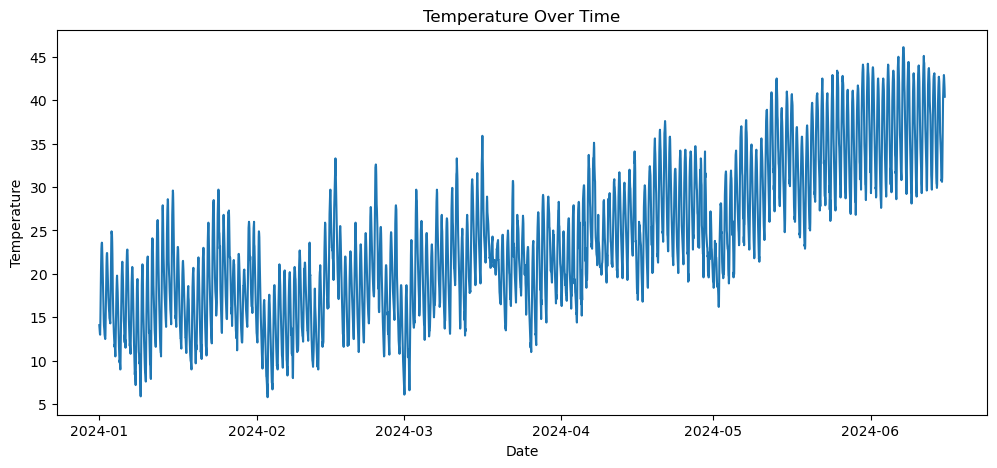

In [27]:
# Visualize temperature over time
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12,5))
plt.plot(merged['time'], merged['temperature_2m'])
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")


**How this helps answer the research question:** This line plot shows how temperature fluctuates hour by hour across the full dataset. It provides context for Research Question 1 (how temperature affects PM2.5) by showing the actual range and pattern of the temperature values being correlated against pollution -- for example, whether temperature swings seasonally or stays fairly flat -- which matters for interpreting how strong or weak any correlation found actually is.

### PM2.5 Trend

Text(0, 0.5, 'PM2.5')

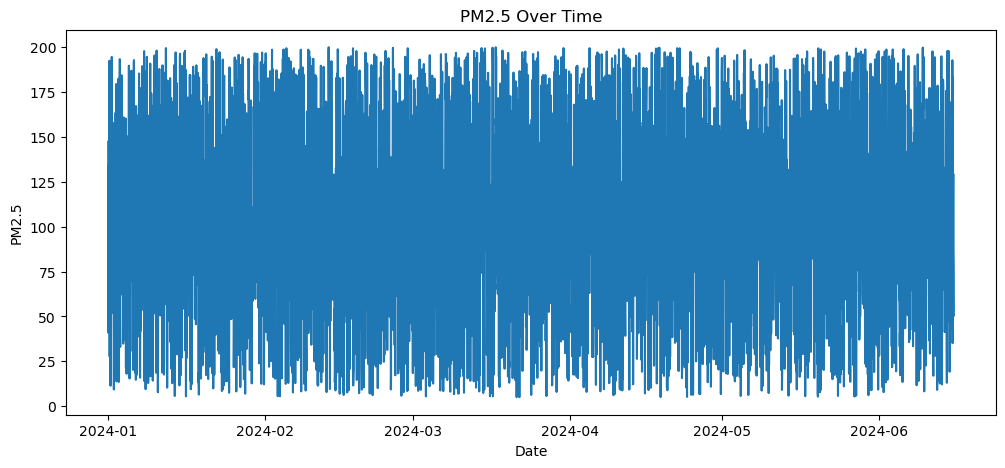

In [28]:
# Visualize PM2.5 over time
plt.figure(figsize=(12,5))
plt.plot(merged['time'], merged['pm2_5'])
plt.title("PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")

**How this helps answer the research question:** This line plot shows how PM2.5 concentration changes over the same time period as the temperature trend above. It directly supports Research Question 3 (average pollution by day) by visually surfacing spikes and periods of elevated pollution that day-by-day averages alone don't make as easy to spot, and it sets up a visual baseline for comparing against the temperature trend.

## Scatter Plot

Text(0.5, 1.0, 'Temperature vs PM2.5')

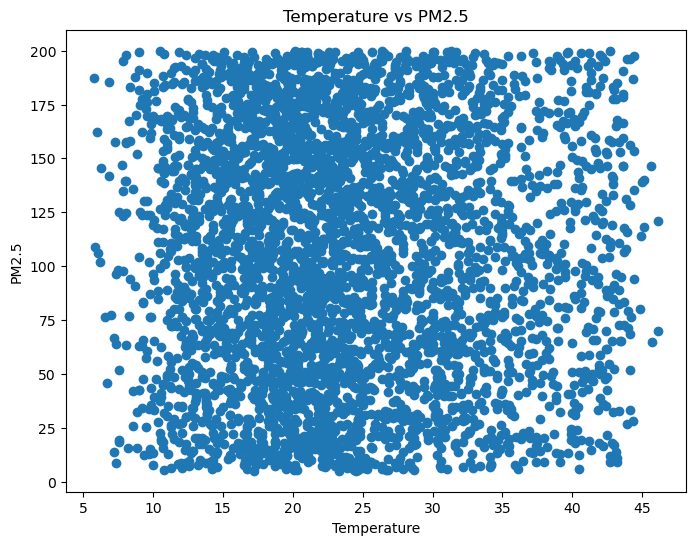

In [29]:
# Visualize temperature vs. PM2.5 to see the shape of the relationship
plt.figure(figsize=(8,6))
plt.scatter(
    merged['temperature_2m'],
    merged['pm2_5']
)

plt.xlabel("Temperature")
plt.ylabel("PM2.5")

plt.title("Temperature vs PM2.5")

**How this helps answer the research question:** This scatter plot directly addresses Research Question 1 (how does temperature affect PM2.5?) by plotting every hourly temperature reading against its corresponding PM2.5 value. Unlike the single correlation coefficient computed earlier, the scatter plot shows the actual shape of the relationship -- whether it looks linear, how much scatter/noise there is, and whether a few outliers are driving the correlation -- which a single number can hide.

## Correlation Heatmap

<Axes: >

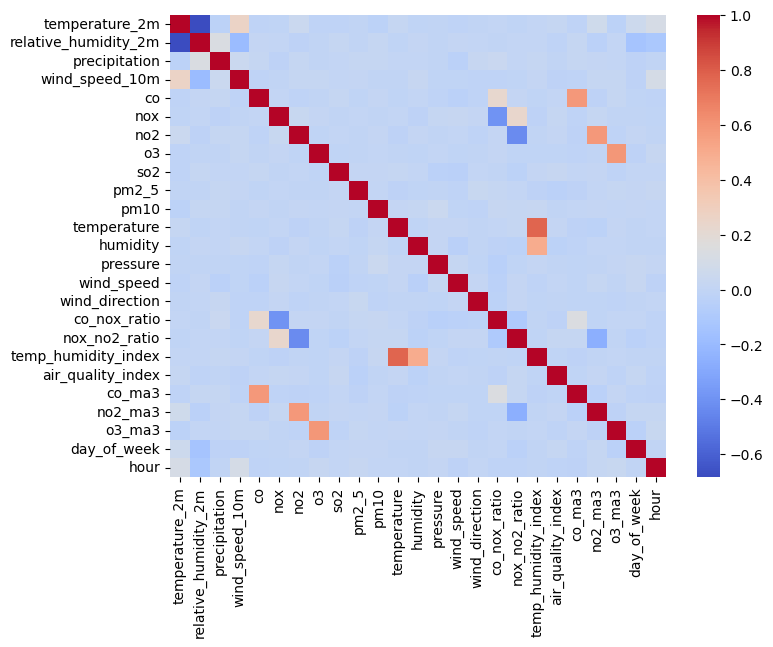

In [30]:
# Correlation heatmap across all numeric variables in the merged dataset
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    merged.corr(numeric_only=True),
    annot=False,
    cmap="coolwarm"
)


**How this helps answer the research question:** This heatmap extends Research Questions 1 and 2 beyond a single pair of variables at a time, showing at a glance how every numeric variable in the merged dataset -- including temperature, wind speed, and all the pollutant measurements -- correlates with `pm2_5` and with each other. It helps confirm whether the temperature/PM2.5 and wind speed/PM2.5 relationships found earlier stand out as meaningfully stronger (or weaker) than other relationships in the data, rather than being isolated coincidences.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* With more time, I would revisit two things in particular. First, on the quality/structure side, I'd dig deeper into whether forward-filling was the right strategy everywhere -- for longer gaps it can quietly propagate stale values, so I'd compare it against interpolation and check how sensitive the final correlations are to that choice. Second, I relied on a single inner merge on timestamp, which drops any hour that isn't present in both datasets and assumes the weather station and the air quality sensor represent the same location closely enough to compare directly; I'd want to confirm that assumption and consider aggregating to daily granularity to reduce hour-to-hour sensor noise. Finally, I'd extend the research questions beyond same-hour correlations to look at lagged effects (e.g., wind speed a few hours earlier), since pollutant dispersion isn't instantaneous, and I'd bring in a third variable like traffic or industrial activity that could be confounding both weather and pollution readings.